# Regression tutorial

This tutorial presents the regression workflow in `Exception-Rules`.

The example uses the `concrete` dataset. The goal is to train a rule-based regressor, inspect the generated rules, and evaluate numerical predictions.

The file `concrete.arff` should be located in the same directory as this notebook.


## Optional plotting dependency

The tutorial uses `matplotlib` only for visualizing the evaluation results. If it is not available in your environment, install it by running the next cell.


In [ ]:
%pip install matplotlib

## Dataset

The `concrete` dataset is a regression dataset stored in ARFF format.

In this tutorial:

- the target column is `class`,
- all other columns are used as descriptive attributes,
- the target is a continuous numerical value.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from exception_rules.regression.algorithm import ExceptionRulesRegressor

## Load data

The dataset is loaded from the current notebook directory.


In [3]:
dataset_path = Path("concrete.arff")

df = pd.DataFrame(arff.loadarff(dataset_path)[0])
object_columns = df.select_dtypes([object])

if not object_columns.empty:
    decoded_columns = object_columns.stack().str.decode("utf-8").unstack()

    for column in decoded_columns:
        df[column] = decoded_columns[column].replace({"?": None})

df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),class
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


## Dataset summary

Before training the model, inspect the dataset size and the distribution of the target variable.


In [4]:
target_column = "class"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Number of examples: {len(df)}")
print(f"Number of attributes: {X.shape[1]}")
print(f"Target column: {target_column}")

display(y.describe().rename("target_summary").to_frame())

Number of examples: 103
Number of attributes: 9
Target column: class


,target_summary
count,103.000000
mean,36.039417
std,7.838232
min,17.190000
25%,30.900000
50%,35.520000
75%,41.205000
max,58.530000


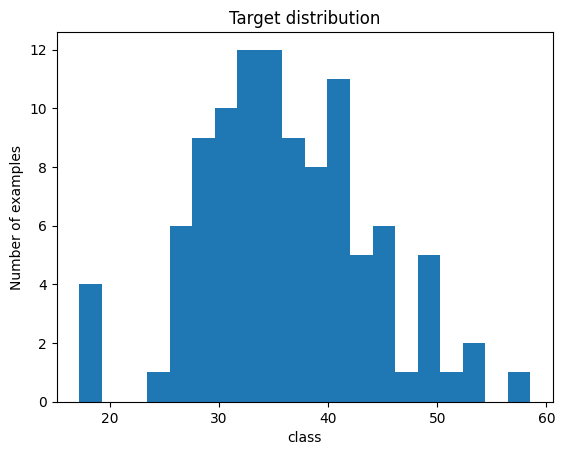

In [5]:
y.plot(kind="hist", bins=20)
plt.title("Target distribution")
plt.xlabel(target_column)
plt.ylabel("Number of examples")
plt.show()

## Train regressor

`ExceptionRulesRegressor` induces commonsense regression rules. When `find_exceptions=True`, it also searches for exception rules and reference rules.

The `induction_measure` parameter selects the rule quality measure used during induction.


In [6]:
regressor = ExceptionRulesRegressor(
    mincov=5,
    induction_measure="c2",
    prune=False,
    find_exceptions=True,
    max_growing=5,
)

model = regressor.fit(X, y)
ruleset = model.ruleset

print(f"Number of commonsense rules: {len(ruleset.rules)}")

Number of commonsense rules: 11


## Generated rules

Each induced commonsense rule may have a reference rule and an exception rule.

The labels below mean:

- `CR` — commonsense rule,
- `RR` — reference rule,
- `ER` — exception rule.


In [7]:
for rule in ruleset.rules:
    print(f"CR: {rule}")

    if rule.exception_rule is not None:
        print(f"RR: {rule.reference_rule}")
        print(f"ER: {rule.exception_rule}")

    print()

CR: IF Water <= 169.25 THEN class = {44.40} [37.62, 51.19] (p=9, n=1, P=38, N=65)
RR: IF Cement >= 178.55 THEN class = {39.37} [31.90, 46.84] (p=35, n=20, P=63, N=40)
ER: IF Water <= 169.25 AND Cement >= 178.55 THEN class = {52.01} [48.23, 55.79] (p=3, n=1, P=8, N=95)

CR: IF Fly ash >= 239.95 AND Cement <= 180.15 AND Fly ash <= 249.00 THEN class = {35.17} [34.38, 35.97] (p=3, n=2, P=7, N=96)

CR: IF Coarse Aggr. >= 1,021.45 THEN class = {31.94} [26.18, 37.70] (p=8, n=1, P=57, N=46)
RR: IF Fly ash <= 219.50 THEN class = {35.03} [26.96, 43.11] (p=52, n=20, P=75, N=28)
ER: IF Coarse Aggr. >= 1,021.45 AND Fly ash <= 219.50 THEN class = {25.17} [19.96, 30.38] (p=1, n=2, P=19, N=84)

CR: IF SLUMP(cm) <= 2.25 AND Cement >= 157.00 AND Fly ash >= 140.00 AND Fly ash <= 239.75 AND Slag <= 160.20 THEN class = {46.39} [40.52, 52.26] (p=7, n=1, P=27, N=76)

CR: IF Fly ash <= 102.50 THEN class = {28.83} [23.45, 34.22] (p=17, n=5, P=43, N=60)
RR: IF Cement <= 165.15 THEN class = {31.60} [25.52, 37.68

## Rules table

For a more compact view, the same rules can be displayed as a table.


In [8]:
rules_table = pd.DataFrame([
    {
        "commonsense_rule": str(rule),
        "reference_rule": str(rule.reference_rule) if rule.reference_rule is not None else "",
        "exception_rule": str(rule.exception_rule) if rule.exception_rule is not None else "",
    }
    for rule in ruleset.rules
])

display(rules_table)

,commonsense_rule,reference_rule,exception_rule
0,IF Water <= 169.25 THEN class = {44.40} [37.62...,IF Cement >= 178.55 THEN class = {39.37} [31.9...,IF Water <= 169.25 AND Cement >= 178.55 THEN c...
1,IF Fly ash >= 239.95 AND Cement <= 180.15 AND ...,,
2,"IF Coarse Aggr. >= 1,021.45 THEN class = {31.9...",IF Fly ash <= 219.50 THEN class = {35.03} [26....,"IF Coarse Aggr. >= 1,021.45 AND Fly ash <= 219..."
3,IF SLUMP(cm) <= 2.25 AND Cement >= 157.00 AND ...,,
4,IF Fly ash <= 102.50 THEN class = {28.83} [23....,IF Cement <= 165.15 THEN class = {31.60} [25.5...,IF Fly ash <= 102.50 AND Cement <= 165.15 THEN...
5,IF Cement <= 162.50 THEN class = {31.69} [26.0...,IF Fly ash <= 155.00 THEN class = {33.18} [25....,IF Cement <= 162.50 AND Fly ash <= 155.00 THEN...
6,IF Fly ash <= 117.50 THEN class = {30.15} [24....,IF Cement <= 263.00 THEN class = {33.63} [26.4...,IF Fly ash <= 117.50 AND Cement <= 263.00 THEN...
7,IF Fly ash >= 239.65 THEN class = {38.95} [32....,IF Cement >= 204.95 THEN class = {39.36} [31.7...,IF Fly ash >= 239.65 AND Cement >= 204.95 THEN...
8,IF FLOW(cm) >= 67.50 AND Cement >= 151.60 AND ...,,
9,IF Water <= 190.50 AND FLOW(cm) >= 58.50 AND C...,,


## Rule summary

The following table shows how many commonsense rules have an associated exception rule.


In [9]:
rule_summary = pd.DataFrame({
    "metric": [
        "commonsense_rules",
        "rules_with_exceptions",
        "rules_without_exceptions",
    ],
    "value": [
        len(ruleset.rules),
        sum(rule.exception_rule is not None for rule in ruleset.rules),
        sum(rule.exception_rule is None for rule in ruleset.rules),
    ],
})

display(rule_summary)

,metric,value
0,commonsense_rules,11
1,rules_with_exceptions,7
2,rules_without_exceptions,4


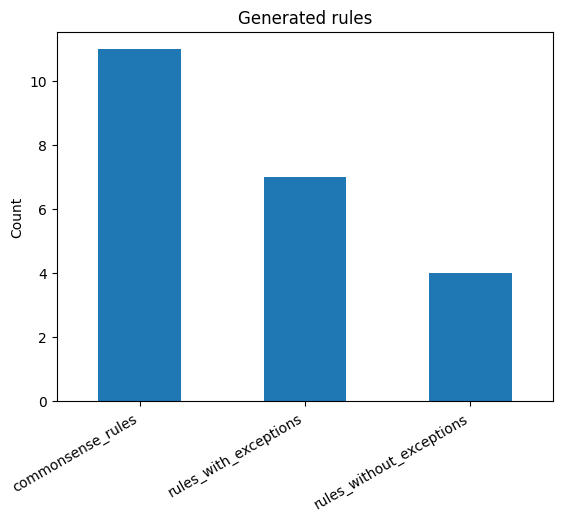

In [10]:
rule_summary.set_index("metric").plot(kind="bar", legend=False)
plt.title("Generated rules")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.show()

## Summary

This tutorial showed how to:

1. load a regression dataset,
2. prepare attributes and the target column,
3. train `ExceptionRulesRegressor`,
4. inspect commonsense, reference and exception rules,
The classification and survival tutorials follow the same documentation style.
